# Holt Winters and ARIMA

# Exponential smoothing

## Historical perspective

 * Developed in the 1950s and 1960s as methods (algorithms) to produce point forecasts.
 * Combine a "level", "trend" (slope) and "seasonal" component to describe a time series.
 * The rate of change of the components are controlled by "smoothing parameters": $\alpha$, $\beta$ and $\gamma$ respectively.
  * Need to choose best values for the smoothing parameters (and initial states).
  * Equivalent ETS state space models developed in the 1990s and 2000s.


## Big idea: control the rate of change

$\alpha$ controls the flexibility of the **level**

* If $\alpha = 0$, the level never updates (mean)
* If $\alpha = 1$, the level updates completely (naive)

$\beta$ controls the flexibility of the **trend**

* If $\beta = 0$, the trend is linear
* If $\beta = 1$, the trend changes suddenly every observation

$\gamma$ controls the flexibility of the **seasonality**

* If $\gamma = 0$, the seasonality is fixed (seasonal means)
* If $\gamma = 1$, the seasonality updates completely (seasonal naive)


## A model for levels, trends, and seasonalities

We want a model that captures the level ($\ell_t$), trend ($b_t$) and seasonality ($s_t$).

>How do we combine these elements?

> **Additively?**
$y_t = \ell_{t-1} + b_{t-1} + s_{t-m} + \varepsilon_t$

>**Multiplicatively?**
$y_t = \ell_{t-1}b_{t-1}s_{t-m}(1 + \varepsilon_t)$

>**Perhaps a mix of both?**
$y_t = (\ell_{t-1} + b_{t-1}) s_{t-m} + \varepsilon_t$

How do the level, trend and seasonal components evolve over time?


## ETS Models

### General Notation

| Component  | Symbol | Description |
|------------|--------|-------------|
| **Error**  | E      | Error |
| **Trend**  | T      | Trend |
| **Seasonality** | S | Seasonality |

### Model Components

- **Error (E):** Additive (`"A"`) or multiplicative (`"M"`).
- **Trend (T):** None (`"N"`), additive (`"A"`), multiplicative (`"M"`), or damped (`"Ad"` or `"Md"`).
- **Seasonality (S):** None (`"N"`), additive (`"A"`), or multiplicative (`"M"`).


# Simple Exponential Smoothing

## Simple Methods

Time series $y_1,y_2,\dots,y_T$.

### Random Walk Forecasts


$$\hat{y}_{T+h|T} = y_T$$

### Average Forecasts

$$
\hat{y}_{T+h|T} = \frac{1}{T} \sum_{t=1}^{T} y_t
$$

- Want something in between these methods.
- Most recent data should have more weight.

## Simple Exponential Smoothing

### Forecast Equation

$$
\hat{y}_{T+1|T} = \alpha y_T + \alpha(1-\alpha) y_{T-1} + \alpha(1-\alpha)^2 y_{T-2} + \cdots, \quad \text{where } 0 \leq \alpha \leq 1.
$$

### Weights Assigned to Observations

| Observation  | $alpha = 0.2$  | $\alpha = 0.4$ | $\alpha = 0.6$ | $\alpha = 0.8$ |
|-------------|----------------|----------------|----------------|----------------|
| $y_{T}$   | $0.2$          | $0.4$          | $0.6$          | $0.8$          |
| $y_{T-1}$ | $0.16$         | $0.24$         | $0.24$         | $0.16$         |
| $y_{T-2}$ | $0.128$        | $0.144$        | $0.096$        | $0.032$        |
| $y_{T-3}$ | $0.1024$       | $0.0864$       | $0.0384$       | $0.0064$       |
| $y_{T-4}$ | $(0.2)(0.8)^4$ | $(0.4)(0.6)^4$ | $(0.6)(0.4)^4$ | $(0.8)(0.2)^4$ |
| $y_{T-5}$ | $(0.2)(0.8)^5$ | $(0.4)(0.6)^5$ | $(0.6)(0.4)^5$ | $(0.8)(0.2)^5$ |


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import numpy as np

In [2]:
ls data

PBS.csv
ansett.csv
aus_livestock.csv
aus_production.csv
aus_retail.csv
cowtemp.json
daily-minimum-temperatures-in-me.csv
daily-total-female-births-CA.csv
eggs.csv
enigma-us.gov_.census.eits_.ressales-e7513e56d76050c05caf638306055c98_1.csv
gafa_stock.csv
global_economy.csv
lynx.csv
olympic_running.csv
pedestrian.csv
strikes-annual-listing.xlsx
tourism.csv
tute1.csv
us_change.csv
us_employment.csv
usdeaths.json
vic_elec.csv


In [3]:
!head data/global_economy.csv

Country,Code,Year,GDP,Growth,CPI,Imports,Exports,Population
Afghanistan,AFG,1960,537777811.111111,NA,NA,7.02479336623182,4.13223321494422,8996351
Afghanistan,AFG,1961,548888895.555556,NA,NA,8.09716629841498,4.45344326574765,9166764
Afghanistan,AFG,1962,546666677.777778,NA,NA,9.34959330590257,4.87805112036481,9345868
Afghanistan,AFG,1963,751111191.111111,NA,NA,16.8639103340214,9.171601094149,9533954
Afghanistan,AFG,1964,800000044.444444,NA,NA,18.0555553858025,8.88889256172819,9731361
Afghanistan,AFG,1965,1006666637.77778,NA,NA,21.4128034842526,11.2582791310323,9938414
Afghanistan,AFG,1966,1399999966.66667,NA,NA,18.571428537415,8.57142877551021,10152331
Afghanistan,AFG,1967,1673333417.77778,NA,NA,14.2098270385479,6.77290842314672,10372630
Afghanistan,AFG,1968,1373333366.66667,NA,NA,15.2103564269331,8.89967664482985,10604346


In [4]:
# load global economy
# parse year
# change year column to Date
# divide population by 1e6
global_economy = pd.read_csv("data/global_economy.csv", parse_dates = ["Year"])
global_economy.columns = ['Country', 'Code', 'Date', 'GDP', 'Growth', 'CPI', 'Imports', 'Exports', 'Population']
global_economy['Population'] = global_economy['Population']/1e6


In [5]:
algeria_economy = global_economy.loc[global_economy['Country']=='Algeria']
algeria_economy.set_index('Date', inplace=True)

algeria_economy.head()

,Country,Code,GDP,Growth,CPI,Imports,Exports,Population
Date,,,,,,,,
1960-01-01,Algeria,DZA,2.723649e+09,NaN,NaN,67.143632,39.043173,11.124888
1961-01-01,Algeria,DZA,2.434777e+09,-13.605441,NaN,67.503771,46.244557,11.404859
1962-01-01,Algeria,DZA,2.001469e+09,-19.685042,NaN,20.818647,19.793873,11.690153
1963-01-01,Algeria,DZA,2.703015e+09,34.313729,NaN,36.825515,24.684682,11.985136
1964-01-01,Algeria,DZA,2.909352e+09,5.839413,NaN,29.439763,25.084059,12.295970


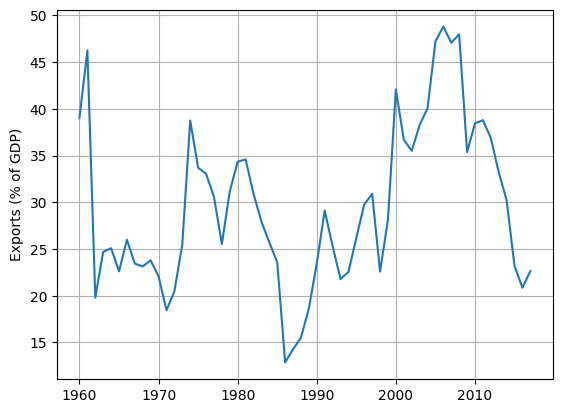

In [6]:
fig, ax = plt.subplots()
ax.plot(algeria_economy.Exports)
ax.set(ylabel='Exports (% of GDP)')
ax.grid()

In [7]:
Y = algeria_economy.Exports
X = Y.index
fit = sm.tsa.SimpleExpSmoothing(Y).fit()
fit.summary()

/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


Dep. Variable:,Exports,No. Observations:,58
Model:,SimpleExpSmoothing,SSE,1995.536
Optimized:,True,AIC,209.217
Trend:,None,BIC,213.338
Seasonal:,None,AICC,209.972
Seasonal Periods:,None,Date:,"Mon, 07 Apr 2025"
Box-Cox:,False,Time:,12:30:13
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.8395372,alpha,True
initial_level,39.043173,l.0,False


In [8]:
fit.fittedfcast

array([39.0431726 , 39.0431726 , 45.0890026 , 23.85280006, 24.55119594,
       24.99855407, 22.98818947, 25.50512875, 23.76668901, 23.23689536,
       23.70022038, 22.33388452, 19.06693854, 20.22770235, 24.65706758,
       36.48780567, 34.13805065, 33.22844003, 31.01048929, 26.4143148 ,
       30.38867165, 33.70466713, 34.44562893, 31.48980936, 28.51112865,
       26.15949053, 23.99721408, 14.64270715, 14.33188326, 15.31916609,
       18.10651123, 22.58726722, 28.06991103, 25.76091781, 22.4220441 ,
       22.51328596, 25.60403378, 29.09349841, 30.61542233, 23.8680045 ,
       27.46299681, 39.72588288, 37.17656258, 35.77283164, 37.85152362,
       39.69993509, 46.0008785 , 48.35981828, 47.27542609, 47.86135509,
       37.3757836 , 38.27305094, 38.70449157, 37.1816181 , 33.84721115,
       30.80129151, 24.39603135, 21.42741042, 22.44448995])

In [9]:
fit.fittedvalues.shape

(58,)

In [10]:
def errorscale(percent):
    return stats.norm.isf((1-percent/100)/2)

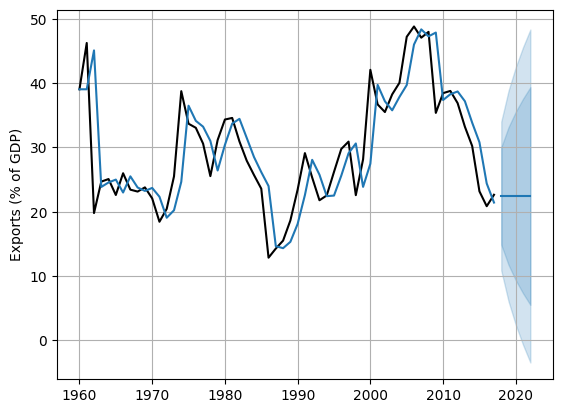

In [11]:
fig, ax = plt.subplots()

ax.plot(Y, 'k')
ax.plot(fit.fittedvalues)
sigma = (Y - fit.fittedvalues).std()


fcast = fit.forecast(5)
dy = sigma*np.sqrt(1+np.arange(len(fcast)))
ax.plot(fcast, color='C0')

s = errorscale(80)
ax.fill_between(fcast.index, fcast - s*dy, fcast + s*dy, color='C0', alpha=0.2)

s = errorscale(95)
ax.fill_between(fcast.index, fcast - s*dy, fcast + s*dy, color='C0', alpha=0.2)

ax.set(ylabel='Exports (% of GDP)')
ax.grid()

## Simple Exponential Smoothing

### Component form

$$
\begin{aligned}
\text{Forecast equation} && \hat{y}_{t+h|t} &= \ell_{t} \\
\text{Smoothing equation} && \ell_{t} &= \alpha y_{t} + (1 - \alpha)\ell_{t-1}
\end{aligned}
$$

* $\ell_t$ is the level (or the smoothed value) of the series at time $t$
* $\hat{y}_{t+1|t} = \alpha y_{t} + (1 - \alpha)\hat{y}{t|t-1}$
* $\hat{y}_{t+h|T} = \ell_T, h=2, 3, ...$

Iterate to get exponentially weighted moving average form.

## Weighted average form
$$\hat{y}_{T+1|T}=\sum_{j=0}^{T-1} \alpha(1-\alpha)^j y_{T-j}+(1-\alpha)^T \ell_{0}$$

## Optimising smoothing parameters

  * Need to choose best values for $\alpha$ and $\ell_0$.
  * Similarly to regression, choose optimal parameters by minimising SSE:
$$
  \text{SSE}=\sum_{t=1}^T(y_t - \hat{y}_{t|t-1})^2.
$$
  * Unlike regression there is no closed form solution --- use numerical optimization.

* For the Algerian Exports example:
    * $\alpha = 0.8395371994368594$
    * $\ell_0 = 39.043172595018$


## Methods with trend

In [12]:
algeria_economy.head(3)

,Country,Code,GDP,Growth,CPI,Imports,Exports,Population
Date,,,,,,,,
1960-01-01,Algeria,DZA,2.723649e+09,NaN,NaN,67.143632,39.043173,11.124888
1961-01-01,Algeria,DZA,2.434777e+09,-13.605441,NaN,67.503771,46.244557,11.404859
1962-01-01,Algeria,DZA,2.001469e+09,-19.685042,NaN,20.818647,19.793873,11.690153


In [13]:
Y = algeria_economy.Exports
X = Y.index
fit = sm.tsa.SimpleExpSmoothing(Y).fit()

/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


In [14]:
fit.params

{'smoothing_level': 0.8395371994368594,
 'smoothing_trend': nan,
 'smoothing_seasonal': nan,
 'damping_trend': nan,
 'initial_level': 39.043172595018,
 'initial_trend': nan,
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [15]:
from IPython.display import display, HTML
display(HTML(fit.summary().as_html()))

Dep. Variable:,Exports,No. Observations:,58
Model:,SimpleExpSmoothing,SSE,1995.536
Optimized:,True,AIC,209.217
Trend:,None,BIC,213.338
Seasonal:,None,AICC,209.972
Seasonal Periods:,None,Date:,"Mon, 07 Apr 2025"
Box-Cox:,False,Time:,12:30:19
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.8395372,alpha,True
initial_level,39.043173,l.0,False


In [16]:
fit.fittedfcast.shape, fit.fittedvalues.shape

((59,), (58,))

In [17]:
def errorscale(percent):
    return stats.norm.isf((1 - percent/100) / 2)

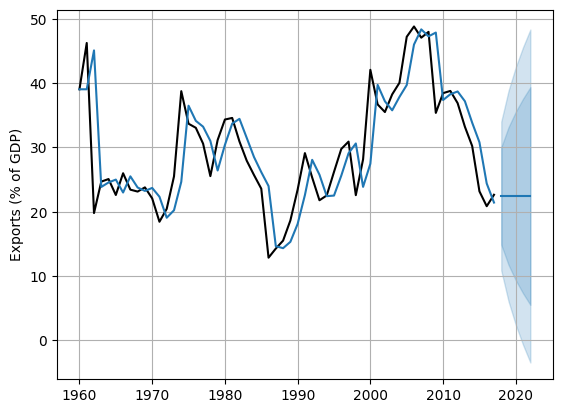

In [18]:
fig, ax = plt.subplots()

ax.plot(Y, 'k')

ax.plot(fit.fittedvalues)
sigma = (Y - fit.fittedvalues).std()

fcast = fit.forecast(5)
ax.plot(fcast, color='C0')
dy = sigma * np.sqrt(1+np.arange(len(fcast)))
s = errorscale(80)
ax.fill_between(fcast.index, fcast - s*dy, fcast + s*dy, color='C0', alpha=.2)
s = errorscale(95)
ax.fill_between(fcast.index, fcast - s*dy, fcast + s*dy, color='C0', alpha=.2)

ax.set(ylabel='Exports (% of GDP)')
ax.grid(True)

In [19]:
Y.index.freq = pd.infer_freq(Y.index)

In [20]:
Y.index.freq

<YearBegin: month=1>

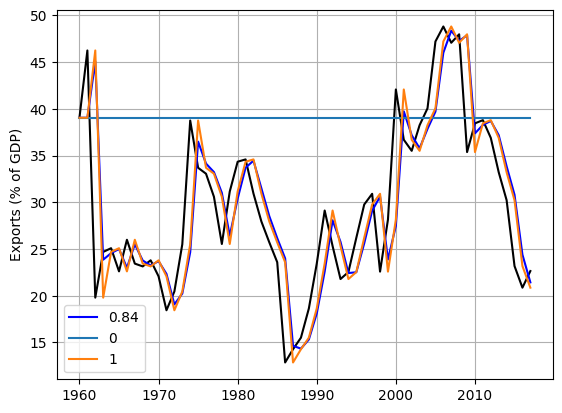

In [23]:
fig, ax = plt.subplots()
fit2 = sm.tsa.SimpleExpSmoothing(Y).fit(smoothing_level=0, optimized=False)
fit3 = sm.tsa.SimpleExpSmoothing(Y).fit(smoothing_level=1, optimized=False)
ax.plot(Y, 'k')

ax.plot(fit.fittedvalues, 'b',label="0.84")
ax.plot(fit2.fittedvalues, label="0") # neste pacote a implementação não condiz com a regra
ax.plot(fit3.fittedvalues, label="1")
ax.set(ylabel='Exports (% of GDP)')
ax.grid(True)
ax.legend()

# Models with trend

## Holt's linear trend

### Component form
$$
\begin{align*}
\text{Forecast }&& \hat{y}_{t+h|t} &= \ell_{t} + hb_{t} \\
\text{Level }&& \ell_{t} &= \alpha y_{t} + (1 - \alpha)(\ell_{t-1} + b_{t-1})\\
\text{Trend }&& b_{t} &= \beta^*(\ell_{t} - \ell_{t-1}) + (1 -\beta^*)b_{t-1},
\end{align*}
$$
  * Two smoothing parameters $\alpha$ and $\beta^*$ ($0\le\alpha,\beta^*\le1$).
  * $\ell_t$ level: weighted average between $y_t$ and one-step ahead forecast for time $t$, $(\ell_{t-1} + b_{t-1}=\hat{y}_{t|t-1})$
  * $b_t$ slope: weighted average of $(\ell_{t} - \ell_{t-1})$ and $b_{t-1}$, current and previous estimate of slope.
  * Choose $\alpha, \beta^*, \ell_0, b_0$ to minimise SSE.




## ETS(A,A,N)

Holt's linear method with additive errors.

  * Assume $\varepsilon_t=y_t-\ell_{t-1}-b_{t-1} \sim \text{NID}(0,\sigma^2)$.
  * Substituting into the error correction equations for Holt's linear method
  \begin{align*}
      y_t&=\ell_{t-1}+b_{t-1}+\varepsilon_t\\
      \ell_t&=\ell_{t-1}+b_{t-1}+\alpha \varepsilon_t\\
      b_t&=b_{t-1}+\alpha\beta^* \varepsilon_t
  \end{align*}
  * For simplicity, set $\beta=\alpha \beta^*$.


## ETS(M,A,N)

Holt's linear method with multiplicative errors.

  * Assume $\varepsilon_t=\frac{y_t-(\ell_{t-1}+b_{t-1})}{(\ell_{t-1}+b_{t-1})}$
  * Following a similar approach as above, the innovations state space model underlying Holt's linear method with multiplicative errors is specified as\vspace*{-0.4cm}
  \begin{align*}
      y_t&=(\ell_{t-1}+b_{t-1})(1+\varepsilon_t)\\
      \ell_t&=(\ell_{t-1}+b_{t-1})(1+\alpha \varepsilon_t)\\
      b_t&=b_{t-1}+\beta(\ell_{t-1}+b_{t-1}) \varepsilon_t
  \end{align*}
  where again  $\beta=\alpha \beta^*$ and $\varepsilon_t \sim \text{NID}(0,\sigma^2)$.

## ETS(A,A,N): Specifying the model

```{r aan-spec, echo = TRUE, eval=FALSE}
ETS(y ~ error("A") + trend("A") + season("N"))
```

By default, optimal values for $\beta$ and $b_0$ are used.

In [24]:
aus_economy = global_economy[global_economy['Code']=="AUS"]
aus_economy.set_index('Date', inplace=True)
aus_economy.index.freq = pd.infer_freq(aus_economy.index)
aus_economy

,Country,Code,GDP,Growth,CPI,Imports,Exports,Population
Date,,,,,,,,
1960-01-01,Australia,AUS,1.857319e+10,NaN,7.960458,14.061746,12.994452,10.276477
1961-01-01,Australia,AUS,1.964834e+10,2.485605,8.142560,15.025080,12.403101,10.483000
1962-01-01,Australia,AUS,1.988801e+10,1.296478,8.116545,12.630927,13.943012,10.742000
1963-01-01,Australia,AUS,2.150185e+10,6.214278,8.168574,13.834054,13.005886,10.950000
1964-01-01,Australia,AUS,2.375854e+10,6.978724,8.402706,13.764495,14.938248,11.167000
1965-01-01,Australia,AUS,2.593124e+10,5.983450,8.688866,15.267340,13.220178,11.388000
1966-01-01,Australia,AUS,2.726173e+10,2.382491,8.975026,15.130228,12.932380,11.651000
1967-01-01,Australia,AUS,3.038974e+10,6.302386,9.287201,13.893495,12.883730,11.799000
1968-01-01,Australia,AUS,3.265763e+10,5.095868,9.521332,14.485597,12.297668,12.009000


In [25]:
fit = sm.tsa.ExponentialSmoothing(aus_economy.Population, trend='add').fit()

In [26]:
display(HTML(fit.summary().as_html()))

Dep. Variable:,Population,No. Observations:,58
Model:,ExponentialSmoothing,SSE,0.223
Optimized:,True,AIC,-314.493
Trend:,Additive,BIC,-306.251
Seasonal:,None,AICC,-312.846
Seasonal Periods:,None,Date:,"Mon, 07 Apr 2025"
Box-Cox:,False,Time:,12:35:28
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,1.0000000,alpha,True
smoothing_trend,0.3248179,beta,True


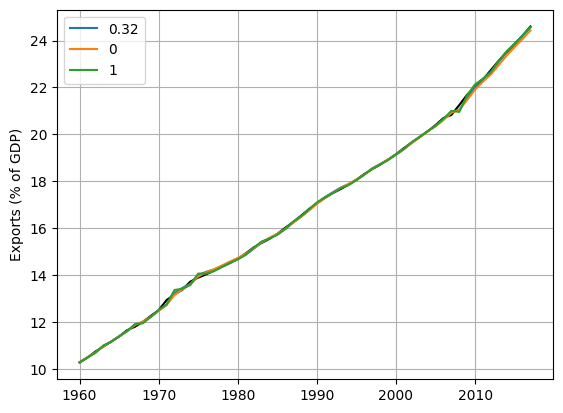

In [27]:
fig, ax = plt.subplots()
fit2 = sm.tsa.ExponentialSmoothing(aus_economy.Population, trend='add').fit(smoothing_level=1, smoothing_trend=0 ,optimized=False)
fit3 = sm.tsa.ExponentialSmoothing(aus_economy.Population, trend='add').fit(smoothing_level=1, smoothing_trend=1, optimized=False)
ax.plot(aus_economy.Population, 'k')

ax.plot(fit.fittedvalues, label="0.32")
ax.plot(fit2.fittedvalues, label="0")  # neste pacote a implementação não condiz com a regra
ax.plot(fit3.fittedvalues, label="1")
ax.set(ylabel='Exports (% of GDP)')
ax.grid(True)
ax.legend()

## Damped trend method

$$
\begin{align*}
\hat{y}_{t+h|t} &= \ell_{t} + (\phi+\phi^2 + \dots + \phi^{h})b_{t} \\
\ell_{t} &= \alpha y_{t} + (1 - \alpha)(\ell_{t-1} + \phi b_{t-1})\\
b_{t} &= \beta^*(\ell_{t} - \ell_{t-1}) + (1 -\beta^*)\phi b_{t-1}.
\end{align*}
$$


  * Damping parameter $0<\phi<1$.
  * If $\phi=1$, identical to Holt's linear trend.
  * As $h\rightarrow\infty$, $\hat{y}_{T+h|T}\rightarrow \ell_T+\phi b_T/(1-\phi)$.
  * Short-run forecasts trended, long-run forecasts constant.

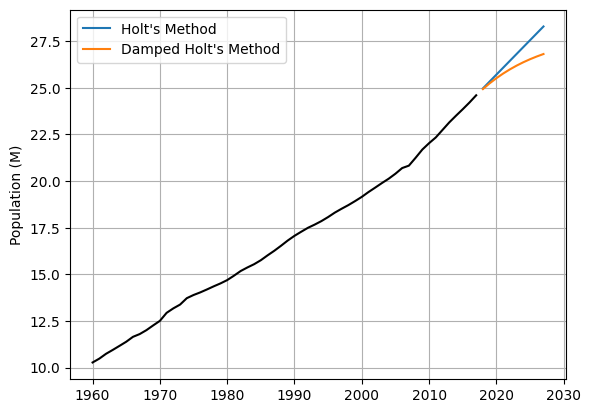

In [28]:
fig, ax = plt.subplots()
ax.plot(aus_economy.Population, 'k')

fit = sm.tsa.ExponentialSmoothing(
    aus_economy.Population, trend='add').fit()
ax.plot(fit.forecast(10), label="Holt's Method")

fit = sm.tsa.ExponentialSmoothing(
    aus_economy.Population, trend='add', damped_trend=True).fit(damping_trend=.9)
ax.plot(fit.forecast(10), label="Damped Holt's Method")

ax.legend(loc='upper left')
ax.set(ylabel='Population (M)')
ax.grid(True)

## Example: Internet usage

In [29]:
import rdatasets

In [30]:
www_usage = rdatasets.data('datasets', 'WWWusage')

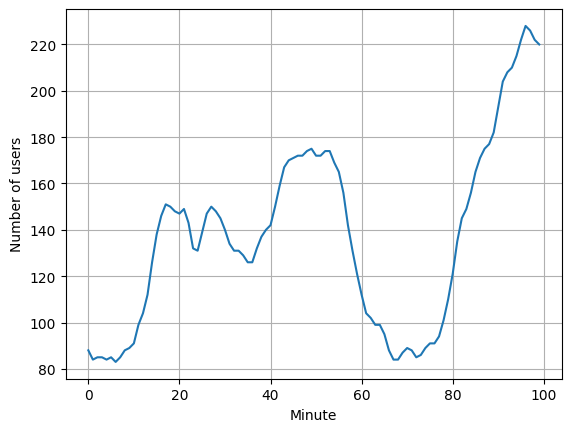

In [31]:
ax = www_usage.value.plot()
ax.set(xlabel='Minute', ylabel='Number of users')
ax.grid(True)

In [32]:
Y = www_usage.value

from statsmodels.tsa.holtwinters import ExponentialSmoothing

ms = dict(
    SES = ExponentialSmoothing(Y).fit(),
    Holt = ExponentialSmoothing(Y, trend='add').fit(),
    DampedHolt = ExponentialSmoothing(Y, trend='add', damped_trend=True).fit()
)


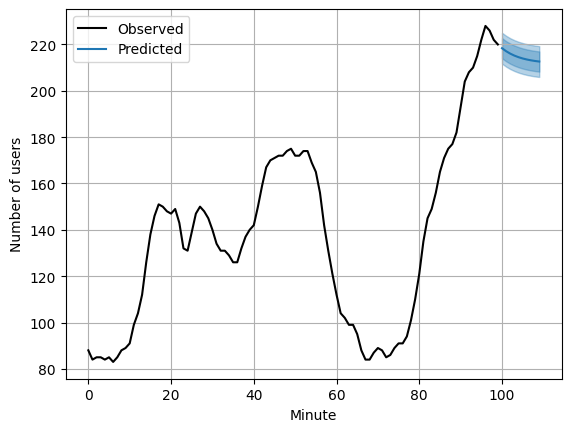

In [33]:
n_forecast = 10
forecast = ms['DampedHolt'].forecast(n_forecast)


x = np.arange(len(Y))
x_forecast = np.arange(len(Y), len(Y) + n_forecast)

resid = ms['DampedHolt'].resid
se = resid.std()
z_95 = 1.96  # 95%
z_80 = 1.28  # 80%

conf_int_95 = (forecast - z_95 * se, forecast + z_95 * se)
conf_int_80 = (forecast - z_80 * se, forecast + z_80 * se)


fig, ax = plt.subplots()
ax.plot(x, Y, 'k', label='Observed')
ax.plot(x_forecast, forecast, label='Predicted', color='C0')
ax.fill_between(x_forecast, conf_int_95[0], conf_int_95[1], alpha=.33, color='C0')
ax.fill_between(x_forecast, conf_int_80[0], conf_int_80[1], alpha=.33, color='C0')

ax.set(xlabel='Minute', ylabel='Number of users')
ax.grid(True)
ax.legend()
plt.show()

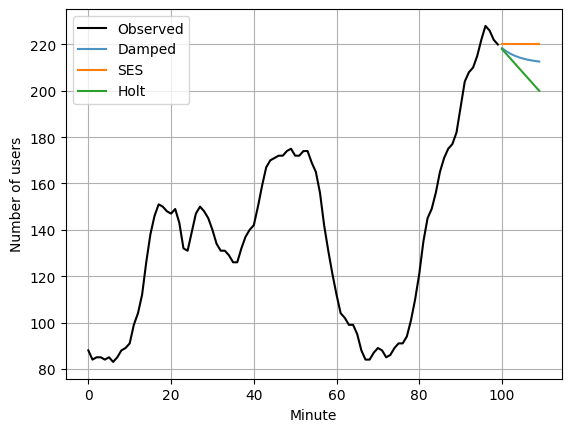

In [39]:
n_forecast = 10
forecast = ms['DampedHolt'].forecast(n_forecast)
forecast1 = ms['SES'].forecast(n_forecast)
forecast2 = ms['Holt'].forecast(n_forecast)


x = np.arange(len(Y))
x_forecast = np.arange(len(Y), len(Y) + n_forecast)


fig, ax = plt.subplots()
ax.plot(x, Y, 'k', label='Observed')
ax.plot(x_forecast, forecast, label='Damped', color='C0', alpha=0.8)
ax.plot(x_forecast, forecast1, label='SES', color='C1')
ax.plot(x_forecast, forecast2, label='Holt', color='C2')

ax.set(xlabel='Minute', ylabel='Number of users')
ax.grid(True)
ax.legend()
plt.show()

In [40]:
def RMSE(Y, y):
    """Root-mean-square error."""
    return np.sqrt(np.mean((Y-y)**2))
def MAE(Y, y):
    """Mean absolute error."""
    return np.mean(np.abs(Y-y))
def MAPE(Y, y):
    """Mean absolute percent error."""
    return 100 * np.mean(np.abs((Y-y)/Y))

def tsaccuracy(Ytest, models):
    """Gather some metrics for a few models."""
    fs = RMSE, MAE, MAPE
    return pd.DataFrame({
        label: [ f(Ytest, model.predict(Ytest.index.min(), Ytest.index.max()))
                for f in (RMSE, MAE, MAPE) ]
        for (label, model) in models.items()
    }, index=[f.__name__ for f in fs]).T

In [76]:
tsaccuracy(Y, ms)

,RMSE,MAE,MAPE
SES,5.770615,4.480000,3.367689
Holt,3.569314,2.920020,2.267468
DampedHolt,3.390711,2.713603,2.108210


## Methods with seasonality

## Holt-Winters additive method

Holt and Winters extended Holt's method to capture seasonality.
### Component form
$$\begin{align*}
\hat{y}_{t+h|t} &= \ell_{t} + hb _{t} + s_{t+h-m(k+1)} \\
\ell_{t} &= \alpha(y_{t} - s_{t-m}) + (1 - \alpha)(\ell_{t-1} + b_{t-1})\\
b_{t} &= \beta^*(\ell_{t} - \ell_{t-1}) + (1 - \beta^*)b_{t-1}\\
s_{t} &= \gamma (y_{t}-\ell_{t-1}-b_{t-1}) + (1-\gamma)s_{t-m}
\end{align*}
$$
* $k=$ integer part of $(h-1)/m$. Ensures estimates from the final year are used for forecasting.

* Parameters:&nbsp; $0\le \alpha\le 1$,&nbsp; $0\le \beta^*\le 1$,&nbsp; $0\le \gamma\le 1-\alpha$&nbsp;  and $m=$  period of seasonality (e.g. $m=4$ for quarterly data).



## Holt-Winters additive method

  * Seasonal component is usually expressed as
        $s_{t} = \gamma^* (y_{t}-\ell_{t})+ (1-\gamma^*)s_{t-m}.$
  * Substitute in for $\ell_t$:
        $s_{t} = \gamma^*(1-\alpha) (y_{t}-\ell_{t-1}-b_{t-1})+ [1-\gamma^*(1-\alpha)]s_{t-m}$
  * We set $\gamma=\gamma^*(1-\alpha)$.
  * The usual parameter restriction is $0\le\gamma^*\le1$, which translates to $0\le\gamma\le(1-\alpha)$.

In [41]:
holidays = pd.read_csv("data/tourism.csv")
holidays['Quarter'] = pd.to_datetime(
    holidays['Quarter'].str.replace(
        r'(\d{4}) Q(\d)',
        lambda m: f'{m.group(1)}-{int(m.group(2))*3-2:02d}-01',
        regex=True
    )
)

In [42]:
holidays.dtypes

Quarter    datetime64[ns]
Region             object
State              object
Purpose            object
Trips             float64
dtype: object

In [43]:
holidays.head()

,Quarter,Region,State,Purpose,Trips
0,1998-01-01,Adelaide,South Australia,Business,135.077690
1,1998-04-01,Adelaide,South Australia,Business,109.987316
2,1998-07-01,Adelaide,South Australia,Business,166.034687
3,1998-10-01,Adelaide,South Australia,Business,127.160464
4,1999-01-01,Adelaide,South Australia,Business,137.448533


In [44]:
!head data/tourism.csv

Quarter,Region,State,Purpose,Trips
1998 Q1,Adelaide,South Australia,Business,135.0776903
1998 Q2,Adelaide,South Australia,Business,109.987316
1998 Q3,Adelaide,South Australia,Business,166.0346866
1998 Q4,Adelaide,South Australia,Business,127.1604643
1999 Q1,Adelaide,South Australia,Business,137.4485333
1999 Q2,Adelaide,South Australia,Business,199.9125861
1999 Q3,Adelaide,South Australia,Business,169.3550898
1999 Q4,Adelaide,South Australia,Business,134.3579372
2000 Q1,Adelaide,South Australia,Business,154.034398


In [45]:
aus_holidays = holidays.loc[holidays['Purpose']=='Holiday'].copy()
aus_holidays = aus_holidays.groupby('Quarter'.split()).Trips.sum().reset_index().set_index('Quarter')
aus_holidays

,Trips
Quarter,
1998-01-01,11806.037622
1998-04-01,9275.662074
1998-07-01,8642.488590
1998-10-01,9299.523781
1999-01-01,11172.027056
...,...
2016-10-01,10084.964670
2017-01-01,12406.418863
2017-04-01,10471.197262


In [46]:
Y = aus_holidays.Trips
m_add = sm.tsa.ExponentialSmoothing(Y, trend='add', seasonal='add').fit()
m_mul = sm.tsa.ExponentialSmoothing(Y, trend='mul', seasonal='mul').fit()

/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


In [47]:
def compute(df, f):
    """Compute new (or replacement) columns."""
    newdf = pd.DataFrame(f(df), index=df.index)
    dropcols = [col for col in newdf.columns if col in df.columns]
    if dropcols:
        df = df.drop(columns=dropcols)
    return df.join(newdf)

holidays = (
    pd.read_csv('data/tourism.csv')
    .pipe(compute, lambda x: dict(
        # Substitui "YYYY Q1" por "YYYY-01-01", "YYYY-04-01" etc.
        date=pd.to_datetime(x.Quarter.str.replace(r'(\d{4}) Q(\d)', lambda m: f'{m.group(1)}-{int(m.group(2))*3-2:02d}-01', regex=True))
    ))
)


In [48]:
aus_holidays

,Trips
Quarter,
1998-01-01,11806.037622
1998-04-01,9275.662074
1998-07-01,8642.488590
1998-10-01,9299.523781
1999-01-01,11172.027056
...,...
2016-10-01,10084.964670
2017-01-01,12406.418863
2017-04-01,10471.197262


In [49]:
Y = aus_holidays.Trips
Y.index.freq = pd.infer_freq(Y.index)
m_add = sm.tsa.ExponentialSmoothing(Y, trend='add', seasonal='add').fit()
m_mul = sm.tsa.ExponentialSmoothing(Y, trend='mul', seasonal='mul').fit()

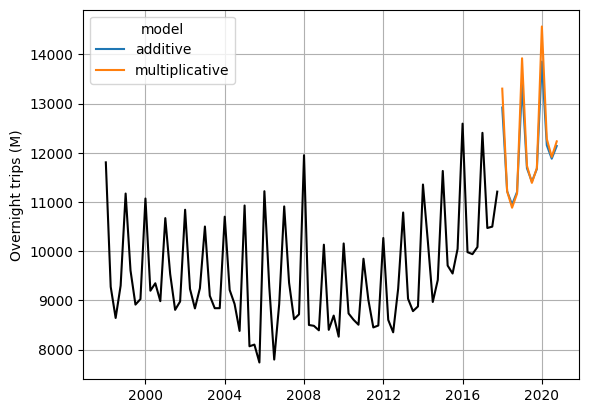

In [50]:
fig, ax = plt.subplots()
ax.plot(Y, 'k')

fc = m_add.forecast(3*4)
ax.plot(fc, label='additive')

fc = m_mul.forecast(3*4)
ax.plot(fc, label='multiplicative')

ax.set(ylabel='Overnight trips (M)')
ax.legend(title='model')

ax.grid(True)


In [51]:
m_add.params_formatted

,name,param,optimized
smoothing_level,alpha,0.242384,True
smoothing_trend,beta,0.145734,True
smoothing_seasonal,gamma,0.033653,True
initial_level,l.0,9726.232858,True
initial_trend,b.0,-19.716034,True
initial_seasons.0,s.0,1502.800195,True
initial_seasons.1,s.1,-274.021914,True
initial_seasons.2,s.2,-681.767111,True
initial_seasons.3,s.3,-524.910060,True


In [52]:
m_mul.params_formatted

,name,param,optimized
smoothing_level,alpha,0.217143,True
smoothing_trend,beta,0.133626,True
smoothing_seasonal,gamma,0.062629,True
initial_level,l.0,9704.028562,True
initial_trend,b.0,0.998926,True
initial_seasons.0,s.0,1.186122,True
initial_seasons.1,s.1,0.987616,True
initial_seasons.2,s.2,0.946872,True
initial_seasons.3,s.3,0.962841,True


In [54]:
def summarize_holt(res):
    d = pd.DataFrame(dict(
        observation=res.data.orig_endog,
        level=res.level,
        season=res.season,
        forecast=res.fittedvalues))
    if res.trend is not None:
        d['slope'] = d['forecast'].diff().fillna(0)
    return d

In [55]:
s_add = summarize_holt(m_add)
s_mul = summarize_holt(m_mul)

In [56]:
s_add.head()

,observation,level,season,forecast,slope
Quarter,,,,,
1998-01-01,11806.037622,9851.152263,1522.881550,11209.317019,0.000000
1998-04-01,9275.662074,9779.113251,-284.213026,9578.492556,-1630.824463
1998-07-01,8642.488590,9661.790918,-696.760225,9088.011325,-490.481232
1998-10-01,9299.523781,9682.217815,-518.592908,9111.808635,23.797310
1999-01-01,11172.027056,9660.230063,1522.389181,11186.657892,2074.849257


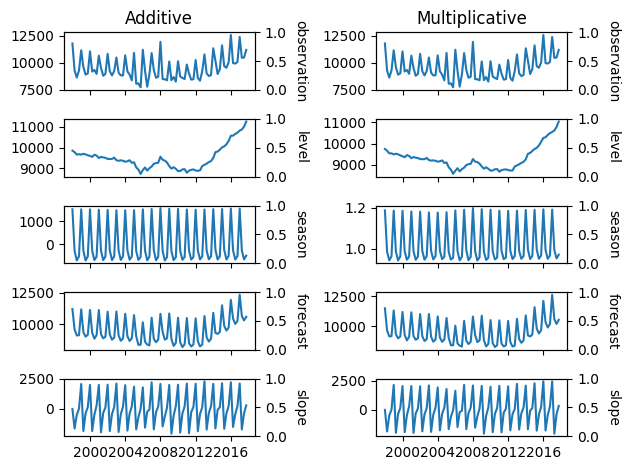

In [57]:
fig, axs = plt.subplots(5, 2, sharex=True)
for (j, s) in enumerate((s_add, s_mul)):
    for (i, field) in enumerate(s_add.columns):
        ax = axs[i,j]
        ax.plot(s[field])
        ax2 = ax.twinx()
        ax2.set_ylabel(field, rotation=270, labelpad=15)
        ax2.grid(False)
axs[0,0].set_title('Additive', size='large')
axs[0,1].set_title('Multiplicative', size='large')
plt.tight_layout()

## Holt-Winters damped method
Often the single most accurate forecasting method for seasonal data:
$$
\begin{align*}
\hat{y}_{t+h|t} &= [\ell_{t} + (\phi+\phi^2 + \dots + \phi^{h})b_{t}]s_{t+h-m(k+1)} \\
\ell_{t} &= \alpha(y_{t} / s_{t-m}) + (1 - \alpha)(\ell_{t-1} + \phi b_{t-1})\\
b_{t} &= \beta^*(\ell_{t} - \ell_{t-1}) + (1 - \beta^*)\phi b_{t-1}       \\
s_{t} &= \gamma \frac{y_{t}}{(\ell_{t-1} + \phi b_{t-1})} + (1 - \gamma)s_{t-m}
\end{align*}
$$

## Holt-Winters with daily data

In [58]:
sth_cross_ped = pd.read_csv('data/pedestrian.csv')
sth_cross_ped['Date_Time'] = pd.to_datetime(sth_cross_ped['Date_Time']).dt.tz_localize(None)
sth_cross_ped

,Sensor,Date_Time,Date,Time,Count
0,Birrarung Marr,2014-12-31 13:00:00,2015-01-01,0,1630
1,Birrarung Marr,2014-12-31 14:00:00,2015-01-01,1,826
2,Birrarung Marr,2014-12-31 15:00:00,2015-01-01,2,567
3,Birrarung Marr,2014-12-31 16:00:00,2015-01-01,3,264
4,Birrarung Marr,2014-12-31 17:00:00,2015-01-01,4,139
...,...,...,...,...,...
66032,Southern Cross Station,2016-12-31 08:00:00,2016-12-31,19,286
66033,Southern Cross Station,2016-12-31 09:00:00,2016-12-31,20,464
66034,Southern Cross Station,2016-12-31 10:00:00,2016-12-31,21,327
66035,Southern Cross Station,2016-12-31 11:00:00,2016-12-31,22,652


In [59]:
sth_cross_ped['Sensor'].value_counts()

Sensor
Southern Cross Station           17539
QV Market-Elizabeth St (West)    17518
Bourke Street Mall (North)       16414
Birrarung Marr                   14566
Name: count, dtype: int64

In [60]:
sth_cross_ped = sth_cross_ped[sth_cross_ped['Sensor']==sth_cross_ped['Sensor'].value_counts().index[0]]

In [61]:
sth_cross_ped = sth_cross_ped[sth_cross_ped['Date_Time']>= '2016-07-01']

In [62]:
sth_cross_ped.set_index('Date_Time', inplace=True)
sth_cross_ped.resample('1d').sum()

,Sensor,Date,Time,Count
Date_Time,,,,
2016-07-01,Southern Cross StationSouthern Cross StationSo...,2016-07-012016-07-012016-07-012016-07-012016-0...,276,11712
2016-07-02,Southern Cross StationSouthern Cross StationSo...,2016-07-022016-07-022016-07-022016-07-022016-0...,276,2361
2016-07-03,Southern Cross StationSouthern Cross StationSo...,2016-07-032016-07-032016-07-032016-07-032016-0...,276,8203
2016-07-04,Southern Cross StationSouthern Cross StationSo...,2016-07-042016-07-042016-07-042016-07-042016-0...,276,17352
2016-07-05,Southern Cross StationSouthern Cross StationSo...,2016-07-052016-07-052016-07-052016-07-052016-0...,276,16265
...,...,...,...,...
2016-12-27,Southern Cross StationSouthern Cross StationSo...,2016-12-272016-12-272016-12-272016-12-272016-1...,276,3446
2016-12-28,Southern Cross StationSouthern Cross StationSo...,2016-12-282016-12-282016-12-282016-12-282016-1...,276,5577
2016-12-29,Southern Cross StationSouthern Cross StationSo...,2016-12-292016-12-292016-12-292016-12-292016-1...,276,4956


In [63]:
sth_cross_ped = sth_cross_ped.resample('1d').sum()
sth_cross_ped.index.freq = pd.infer_freq(sth_cross_ped.index)
sth_cross_ped

,Sensor,Date,Time,Count
Date_Time,,,,
2016-07-01,Southern Cross StationSouthern Cross StationSo...,2016-07-012016-07-012016-07-012016-07-012016-0...,276,11712
2016-07-02,Southern Cross StationSouthern Cross StationSo...,2016-07-022016-07-022016-07-022016-07-022016-0...,276,2361
2016-07-03,Southern Cross StationSouthern Cross StationSo...,2016-07-032016-07-032016-07-032016-07-032016-0...,276,8203
2016-07-04,Southern Cross StationSouthern Cross StationSo...,2016-07-042016-07-042016-07-042016-07-042016-0...,276,17352
2016-07-05,Southern Cross StationSouthern Cross StationSo...,2016-07-052016-07-052016-07-052016-07-052016-0...,276,16265
...,...,...,...,...
2016-12-27,Southern Cross StationSouthern Cross StationSo...,2016-12-272016-12-272016-12-272016-12-272016-1...,276,3446
2016-12-28,Southern Cross StationSouthern Cross StationSo...,2016-12-282016-12-282016-12-282016-12-282016-1...,276,5577
2016-12-29,Southern Cross StationSouthern Cross StationSo...,2016-12-292016-12-292016-12-292016-12-292016-1...,276,4956


In [64]:
split = '2016-08-01'
dtrain, dtest = sth_cross_ped[:split], sth_cross_ped[split:'2016-09-01']

In [65]:
m = sm.tsa.ExponentialSmoothing(dtrain.Count, trend='add', damped_trend=True, seasonal='mul').fit()

/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [66]:
RMSE(dtrain.Count, m.fittedvalues)

435.711101265182

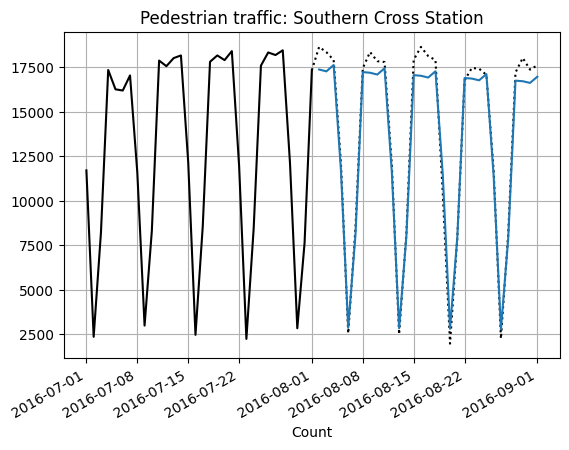

In [67]:
fig, ax = plt.subplots()
ax.plot(dtrain.Count, 'k')
ax.plot(dtest.Count, 'k:')

fc = m.forecast(31)
ax.plot(fc)
ax.set(xlabel='Count')
ax.set_title('Pedestrian traffic: Southern Cross Station')
fig.autofmt_xdate()
ax.grid(True)


In [68]:
RMSE(dtest.Count, fc)

736.0951549893562

In [69]:
def ciclean(ci_df):
    """Clean up conf_int() result column names."""
    ci_df = ci_df.copy()
    ci_df.columns = 'lower', 'upper'
    return ci_df

In [70]:
m = sm.tsa.statespace.ExponentialSmoothing(
    dtrain.Count,
    trend=True,
    seasonal=7,
    damped_trend=True
).fit()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           12     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  8.02394D+00    |proj g|=  5.58866D-02

At iterate    5    f=  7.68104D+00    |proj g|=  1.91309D-03

At iterate   10    f=  7.61061D+00    |proj g|=  9.67664D-04

At iterate   15    f=  7.60607D+00    |proj g|=  2.40073D-03

At iterate   20    f=  7.56516D+00    |proj g|=  6.30673D-03

At iterate   25    f=  7.56091D+00    |proj g|=  3.23155D-05

At iterate   30    f=  7.56090D+00    |proj g|=  1.02366D-03

At iterate   35    f=  7.55985D+00    |proj g|=  1.03384D-02

At iterate   40    f=  7.55634D+00    |proj g|=  2.02886D-04

At iterate   45    f=  7.55323D+00    |proj g|=  9.42537D-04

At iterate   50    f=  7.55311D+00    |proj g|=  7.12928D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cau

 This problem is unconstrained.
/Users/gabrielasoares/.local/share/virtualenvs/times_series-ymuiMkMa/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


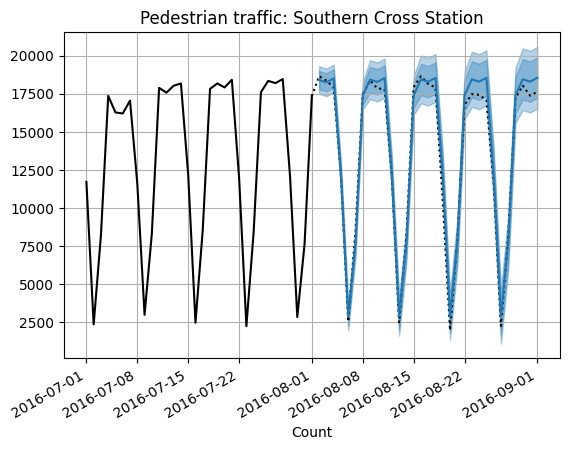

In [71]:
fig, ax = plt.subplots()
ax.plot(dtrain.Count, 'k')
ax.plot(dtest[:'2016-09-01'].Count, 'k:')

fc = m.get_forecast(31)
ax.plot(fc.predicted_mean)

ci = ciclean(fc.conf_int())
ax.fill_between(ci.index, ci.lower, ci.upper, color='C0', alpha=.33)
ci = ciclean(fc.conf_int(alpha=.2))
ax.fill_between(ci.index, ci.lower, ci.upper, color='C0', alpha=.33)

ax.set(xlabel='Count')
ax.set_title('Pedestrian traffic: Southern Cross Station')
fig.autofmt_xdate()
ax.grid(True)

In [72]:
RMSE(dtest.Count, fc.predicted_mean)

670.205002936341

We can also fit in logspace to obtain an effectively multiplicative model.

In [73]:
m = sm.tsa.statespace.ExponentialSmoothing(
    np.log1p(dtrain.Count),
    trend=True,
    seasonal=7,
    damped_trend=True
).fit()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           12     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -1.26061D+00    |proj g|=  1.45279D+01

At iterate    5    f= -1.43279D+00    |proj g|=  5.73725D+00

At iterate   10    f= -1.47605D+00    |proj g|=  1.51572D-01

At iterate   15    f= -1.47621D+00    |proj g|=  2.67793D-01

At iterate   20    f= -1.47701D+00    |proj g|=  2.49940D-01

At iterate   25    f= -1.49094D+00    |proj g|=  2.20511D+00

At iterate   30    f= -1.51643D+00    |proj g|=  6.07219D-01

At iterate   35    f= -1.53019D+00    |proj g|=  7.00823D-01

At iterate   40    f= -1.53441D+00    |proj g|=  5.15762D-01

At iterate   45    f= -1.53598D+00    |proj g|=  1.41456D-01

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = nu

 This problem is unconstrained.


In [74]:
e1 = np.expm1

In [75]:
RMSE(dtrain.Count, e1(m.fittedvalues))

423.5666985222926

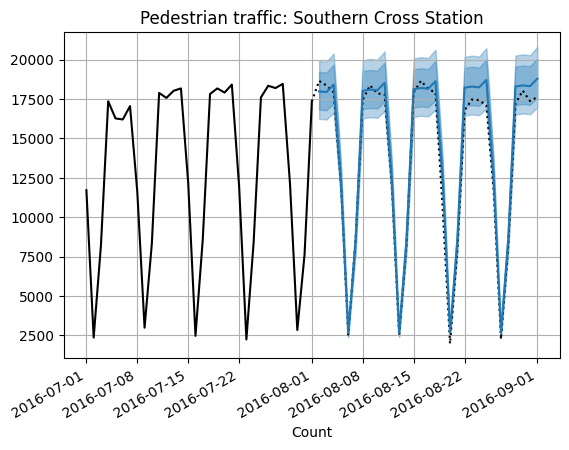

In [77]:
fig, ax = plt.subplots()
ax.plot(dtrain.Count, 'k')
ax.plot(dtest[:'2016-09-01'].Count, 'k:')

fc = m.get_forecast(31)
ax.plot(e1(fc.predicted_mean))

ci = ciclean(fc.conf_int())
ax.fill_between(ci.index, e1(ci.lower), e1(ci.upper), color='C0', alpha=.33)
ci = ciclean(fc.conf_int(alpha=.2))
ax.fill_between(ci.index, e1(ci.lower), e1(ci.upper), color='C0', alpha=.33)

ax.set(xlabel='Count')
ax.set_title('Pedestrian traffic: Southern Cross Station')
fig.autofmt_xdate()
ax.grid(True)

In [167]:
RMSE(dtest.Count, e1(fc.predicted_mean))

np.float64(758.6889901755405)

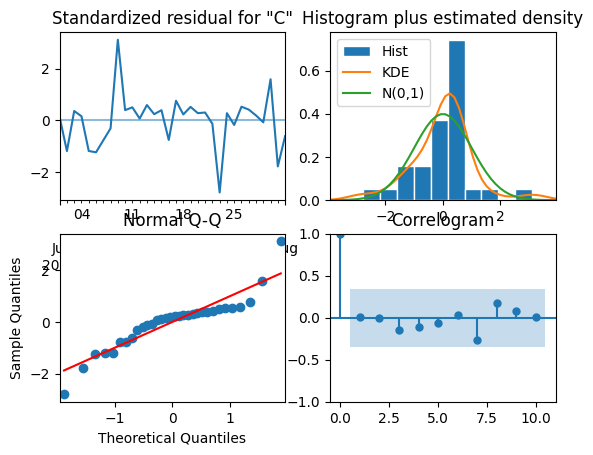

In [78]:
m.plot_diagnostics();

## Exercise

Apply Holt-Winters’ multiplicative method to the Gas data from `aus_production`.

 1. Why is multiplicative seasonality necessary here?
 1. Experiment with making the trend damped.
 1. Check that the residuals from the best method look like white noise.